# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

Nuestro objetivo principal es comparar cuál es la mejor de las dos tarifas de prepago y cuál es la mas conveniente para nuestra empresa, la cuál le genere mejores ingresos, para esto debemos cargar los datos, prepararlos para su analisis, corregirlos, analizar los datos y por último realizar una prueba de hipotesis.

In [67]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

## Cargar datos

In [68]:
# Carga los archivos de datos en diferentes DataFrames
calls = pd.read_csv("megaline_calls.csv")
internet = pd.read_csv("megaline_internet.csv")
messages = pd.read_csv("megaline_messages.csv")
plans = pd.read_csv("megaline_plans.csv")
users= pd.read_csv("megaline_users.csv") 

## Preparar los datos

In [69]:
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [70]:
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [71]:
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [72]:
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [73]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Por el momento no hacemos ninguna corrección, solo nos esta mostrando el contenido que contiene cada tabla.

## Tarifas

In [74]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [75]:
# Imprime una muestra de los datos para las tarifas
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


En nuestra tabla anterior vemos que comparandola  con las descripción de la tarifa  surf tenemos que cambiar la columna mb_per_month_included tanto el nombre como tambien cambiar su contenido es decir  convertir los megabytes a gigabytes, como se demostrará a continuación.

## Corregir datos

No hay correcciones que hacer aqui por el momento.

## Enriquecer los datos

In [76]:
plans["mb_per_month_included"] = plans["mb_per_month_included"]/1024
plans = plans.rename(columns={"mb_per_month_included":"gb_per_month_included"})

In [77]:
plans

,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


En este paso de Enriquecimiento de datos primero tuvimos que calcular o convertir  la columna mb_per_month_included donde 1 gigabyte es igual a 1024 megabytes entonces dividimos 15360 entre 1024, y posteriomente cambiamos el nombre de la columna con el método rename utilizando también la forma diccionarios en nuestros parametros.

## Usuarios/as

In [78]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [79]:
# Imprime una muestra de datos para usuarios
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


En esta tabla observamos que la columnas churn_date y reg_date tenemos que modificarlas, en la primera tenemos que limpiar los valores NaN y de la segunda hay que cambiar la fecha de object a la forma detetime de fechas.

### Corregir los datos

In [80]:
users[users["churn_date"].isna()]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN


In [81]:
# calcular la proporcion de nulos
no_nulos = users["churn_date"].isna().sum()
total_val = len(users)

print("proporcion de nulos")
no_nulos/total_val

proporcion de nulos


np.float64(0.932)

In [82]:
# corregir fecha
users["reg_date"] = pd.to_datetime(users["reg_date"])
users["reg_date"].dtype

dtype('<M8[ns]')

Para corregir los datos empezamos calculando la proporción de nulos e implementando los metodos isna() y sum(), sacamos el total de valores con el metodo len () y dividimos los no_nulos entre total_valores para sacar la proporción de nulos dandonos un 93.2 % como hay una condición % donde de 0 a 5 puedo eliminar, de 5 a 10 puedo imputar y mas del 10 % existen técnicas avanzadas, y no las conocemos este porcentaje se queda asi.
Y para corregir la fecha utilizamos la columna reg_date junto con el metodo to_datetime para cambiar la fecha.

1.7.2. Enriquecer los datos

In [83]:
users["month"] = users["reg_date"].dt.month
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,12
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,8
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN,10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN,1
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN,5


Aqui se extrajo el mes de la columna reg_date junto con el metodo dt.month y aplicamos un head() para que muestre ahora la columna month

## Llamadas

In [84]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [85]:
# Imprime una muestra de datos para las llamadas
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


En esta tabla observamos que tenemos que cambiar la columna call_date de object a la forma datetime de fechas.

### Corregir los datos

In [86]:
# corregir fecha
calls["call_date"] = pd.to_datetime(calls["call_date"],format='%Y-%m-%d')
calls["call_date"].dtype

dtype('<M8[ns]')

### Enriquecer los datos

In [87]:
calls["mes"]=pd.DatetimeIndex(calls["call_date"]).month
calls

,id,user_id,call_date,duration,mes
0,1000_93,1000,2018-12-27,8.52,12
1,1000_145,1000,2018-12-27,13.66,12
2,1000_247,1000,2018-12-27,14.48,12
3,1000_309,1000,2018-12-28,5.76,12
4,1000_380,1000,2018-12-30,4.22,12
...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72,11
137731,1499_200,1499,2018-10-20,10.89,10
137732,1499_201,1499,2018-09-21,8.12,9
137733,1499_202,1499,2018-10-10,0.37,10



Para corregir la fecha utilizamos la columna call_date junto con el metodo to_datetime para cambiar la fecha.
Y Aqui extraemos los meses de la columna call_date junto con el metodo dt.month y aplicamos un head() para que muestre ahora la columna mes.

## Mensajes

In [88]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [89]:
# Imprime una muestra de datos para los mensajes
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


En esta tabla observamos que tenemos que cambiar la columna message_date de object a la forma datetime de fechas.

### Corregir los datos

In [90]:
messages["message_date"] = pd.to_datetime(messages["message_date"],format='%Y-%m-%d')
messages["message_date"].dtype

dtype('<M8[ns]')

### Enriquecer los datos

In [91]:
messages["mes"]=pd.DatetimeIndex(messages["message_date"]).month
messages

,id,user_id,message_date,mes
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12
...,...,...,...,...
76046,1497_526,1497,2018-12-24,12
76047,1497_536,1497,2018-12-24,12
76048,1497_547,1497,2018-12-31,12
76049,1497_558,1497,2018-12-24,12


Para corregir la fecha utilizamos la columna message_date junto con el metodo to_datetime para cambiar la fecha.
Y Aqui extraemos el mes de la columna message_date junto con el metodo dt.month y aplicamos un head() para que muestre ahora la columna mes.


## Internet

In [92]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [93]:
# Imprime una muestra de datos para el tráfico de internet
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


En esta tabla observamos que tenemos que cambiar la columna session_date de object a la forma datetime de fechas.

### Corregir los datos

In [94]:
internet["session_date"] = pd.to_datetime(internet["session_date"],format='%Y-%m-%d')
internet["session_date"].dtype

dtype('<M8[ns]')

### Enriquecer los datos

In [95]:
#internet["gb_used"]=np.ceil(internet["mb_used"]/1024)
internet["mes"]=pd.DatetimeIndex(internet["session_date"]).month
internet

,id,user_id,session_date,mb_used,mes
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12
...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06,10
104821,1499_216,1499,2018-12-30,304.72,12
104822,1499_217,1499,2018-09-22,292.75,9
104823,1499_218,1499,2018-12-07,0.00,12


Para corregir la fecha utilizamos la columna session_date junto con el metodo to_datetime para cambiar la fecha.
Y Aqui extraemos los meses de la columna session_date junto con el metodo dt.month y aplicamos un head() para que muestre ahora la columna mes.

## Estudiar las condiciones de las tarifas

In [96]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans

,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


Aqui ya tenemos la tabla ya modificada  es decir la columna gb_per_month_included y su contenido.

## Agregar datos por usuario

In [97]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
num_llamadas = calls.groupby(["user_id","mes"])["id"].count().reset_index(name="num_llamadas")
num_llamadas

,user_id,mes,num_llamadas
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64
...,...,...,...
2253,1498,12,39
2254,1499,9,41
2255,1499,10,53
2256,1499,11,45


Aqui calculamos el numero de llamadas hechas por cada usuario es decir usamos nuestra variable calls utilizamos los métodos groupby(), count() y reset_index y la guardamos en una nueva variable.

In [98]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
tot_duration = calls.groupby(["user_id","mes"])["duration"].sum().reset_index(name="tot_duration")
tot_duration

,user_id,mes,tot_duration
0,1000,12,116.83
1,1001,8,171.14
2,1001,9,297.69
3,1001,10,374.11
4,1001,11,404.59
...,...,...,...
2253,1498,12,324.77
2254,1499,9,330.37
2255,1499,10,363.28
2256,1499,11,288.56


Aqui sacamos la cantidad de minutos usados por cada cliente es decir utilizamos nuestra variable calls y utilizamos los métodos groupby(), sum() y reset_index() y guardamos en una nueva variable.

In [99]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
num_message = messages.groupby(["user_id","mes"])["id"].count().reset_index(name="num_message")
num_message

,user_id,mes,num_message
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


Aqui sacamos el numero de mensajes utilizados por los clientes al mes es decir utilizamos nuestra variable message y los métodos groupby(),count() y reset_index() y la guardamos en una variable nueva.

In [100]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
vol_traf = internet.groupby(["user_id","mes"])["mb_used"].sum().reset_index(name="vol_traf")
vol_traf

,user_id,mes,vol_traf
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30
...,...,...,...
2272,1498,12,23137.69
2273,1499,9,12984.76
2274,1499,10,19492.43
2275,1499,11,16813.83


Aqui calculamos el volumen de internet usados por los clientes al mes es decir utilizamos nuestra variable internet y los métodos groupby(), sum() y reset_index() y la guardamos en una nueva variable.

In [101]:
#funcion para calcular los GB
def redondeo(mb):
    return math.ceil(mb/1024)

#crear columna con los GB
vol_traf["gb_used"]=vol_traf["vol_traf"].apply(redondeo)
vol_traf.head()

,user_id,mes,vol_traf,gb_used
0,1000,12,1901.47,2
1,1001,8,6919.15,7
2,1001,9,13314.82,14
3,1001,10,22330.49,22
4,1001,11,18504.30,19


Aqui usamos una función donde se calculen los megas a gigas donde cree una columna y vaya registrando los gigabytes esto nos servira mas adelante.

In [102]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
df_mes = num_llamadas.merge(tot_duration,on=["user_id","mes"],how="outer")
df_mes = df_mes.merge(num_message,on=["user_id","mes"],how="outer")
df_mes = df_mes.merge(vol_traf,on=["user_id","mes"],how="outer")
df_mes


,user_id,mes,num_llamadas,tot_duration,num_message,vol_traf,gb_used
0,1000,12,16.0,116.83,11.0,1901.47,2.0
1,1001,8,27.0,171.14,30.0,6919.15,7.0
2,1001,9,49.0,297.69,44.0,13314.82,14.0
3,1001,10,65.0,374.11,53.0,22330.49,22.0
4,1001,11,64.0,404.59,36.0,18504.30,19.0
...,...,...,...,...,...,...,...
2288,1498,12,39.0,324.77,NaN,23137.69,23.0
2289,1499,9,41.0,330.37,NaN,12984.76,13.0
2290,1499,10,53.0,363.28,NaN,19492.43,20.0
2291,1499,11,45.0,288.56,NaN,16813.83,17.0


Aqui juntamos todos nuestra variables en un solo dataframe utilizando las columnas user_id y month y utilizando el metodo merge().

In [103]:
new = users[["user_id","city","plan"]]
new

,user_id,city,plan
0,1000,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate
1,1001,"Seattle-Tacoma-Bellevue, WA MSA",surf
2,1002,"Las Vegas-Henderson-Paradise, NV MSA",surf
3,1003,"Tulsa, OK MSA",surf
4,1004,"Seattle-Tacoma-Bellevue, WA MSA",surf
...,...,...,...
495,1495,"New York-Newark-Jersey City, NY-NJ-PA MSA",surf
496,1496,"New Orleans-Metairie, LA MSA",surf
497,1497,"Los Angeles-Long Beach-Anaheim, CA MSA",ultimate
498,1498,"New York-Newark-Jersey City, NY-NJ-PA MSA",surf


In [104]:
# Añade la información de la tarifa
infor = pd.merge(df_mes,new)
infor_tarif = pd.merge(infor,plans,right_on="plan_name",left_on="plan").fillna(0)
infor_tarif.head()

,user_id,mes,num_llamadas,tot_duration,num_message,vol_traf,gb_used,city,plan,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,16.0,116.83,11.0,1901.47,2.0,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,1000,30.0,3000,70,7,0.01,0.01,ultimate
1,1001,8,27.0,171.14,30.0,6919.15,7.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf
2,1001,9,49.0,297.69,44.0,13314.82,14.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf
3,1001,10,65.0,374.11,53.0,22330.49,22.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf
4,1001,11,64.0,404.59,36.0,18504.30,19.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf


Aqui fusionamos o juntamos nuestras tablas con nuestras variables infor_tarif y new para hacer una sola utilizando el método merge() y fillna() para rellenar algún número auscente que contenga la tabla.

In [105]:
# Calcula el ingreso mensual para cada usuario

def ingresos(data):
    #tarifa base mensual
    ta_b=data["usd_monthly_pay"]

    #ingreso minutos
    exceso_min=max(0,data["tot_duration"]-data["minutes_included"])
    ingreso_min=exceso_min*data["usd_per_minute"]

    #ingreso mensajes
    exceso_msg=max(0,data["num_message"]-data["messages_included"])
    ingreso_msg=exceso_msg*data["usd_per_message"]

    #ingreso internet
    exceso_int=max(0,data["gb_used"]-data["gb_per_month_included"])
    ingreso_int=exceso_int*data["usd_per_gb"]

    return ta_b+ingreso_min+ingreso_msg+ingreso_int
    
    

In [106]:
#infor_tarif.apply(ingresos,axis=1)
infor_tarif["ingresos"]=infor_tarif.apply(ingresos,axis=1)
infor_tarif.head()


,user_id,mes,num_llamadas,tot_duration,num_message,vol_traf,gb_used,city,plan,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,ingresos
0,1000,12,16.0,116.83,11.0,1901.47,2.0,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,1000,30.0,3000,70,7,0.01,0.01,ultimate,70.00
1,1001,8,27.0,171.14,30.0,6919.15,7.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf,20.00
2,1001,9,49.0,297.69,44.0,13314.82,14.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf,20.00
3,1001,10,65.0,374.11,53.0,22330.49,22.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf,90.09
4,1001,11,64.0,404.59,36.0,18504.30,19.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,surf,60.00


Aqui calculamos el ingreso mensual para cada cliente utilizando una función def donde se plantea a cada uno los minutos, mensajes e internet regresará el costo y también llamamos a nuestra variable infor_tarif y la columna ingresos junto con el método apply() para que lo registre en la columna ingresos.

## Estudia el comportamiento de usuario

### Llamadas

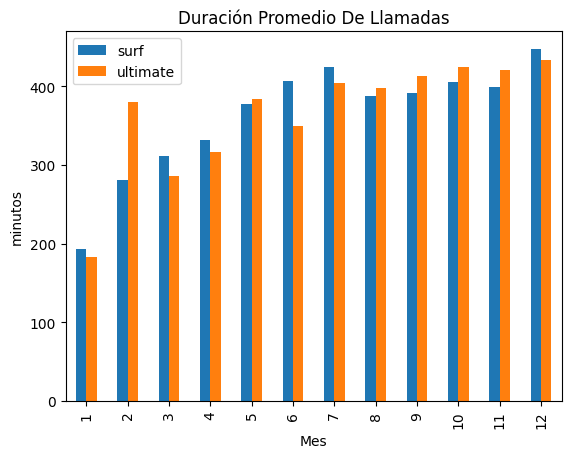

In [107]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. 
#paso 1:filtrar por plan

surf = infor_tarif[infor_tarif["plan_name"]=="surf"]
ultimate = infor_tarif[infor_tarif["plan_name"]=="ultimate"]

#paso 2:resumir por mes los minutos usados
surf_min = surf.groupby("mes")["tot_duration"].mean()
ult_min = ultimate.groupby("mes")["tot_duration"].mean()

#paso 3:unir la información
surf_ult = pd.concat([surf_min,ult_min],axis=1)

#paso 4:graficar
surf_ult.plot(kind="bar",
              title="Duración Promedio De Llamadas",
              xlabel="Mes",
              ylabel="minutos",
             )
plt.legend(["surf","ultimate"])
plt.show();


Aqui sacamos la duración promedio de llamadas por cada plan y cada mes, primero filtramos por cada plan, segundo resumimos por mes los minutos utilizando el método groupby(),la columna tot_duration y usando también el metodo mean(), unimos la informacion utilizando el método concat()y el parametro axis=1 y por último graficamos.

In [108]:
# Calcula la media y la varianza de la duración mensual de llamadas.

surf_min_prom = surf.groupby("mes")["tot_duration"].mean()
surf_min_var = surf.groupby("mes")["tot_duration"].var()


ult_min_prom = ultimate.groupby("mes")["tot_duration"].mean()
ult_min_var = ultimate.groupby("mes")["tot_duration"].var()
print(f"el promedio de la duración mensual de llamadas para surf es:{surf_min_prom} ")
print(f"la varianza de la duración mensual de llamadas para surf es:{surf_min_var} ")
print(f"el promedio de la duración mensual de llamadas para ultimate es:{ult_min_prom} ")
print(f"la varianza de la duración mensual de llamadas para ultimate es:{ult_min_var} ")



el promedio de la duración mensual de llamadas para surf es:mes
1     192.840000
2     280.851111
3     310.970000
4     332.380000
5     377.053247
6     407.208866
7     424.523223
8     387.169630
9     390.992062
10    405.692363
11    399.599823
12    447.475283
Name: tot_duration, dtype: float64 
la varianza de la duración mensual de llamadas para surf es:mes
1     14795.440200
2     46959.219961
3     31821.317991
4     45615.666796
5     53282.922217
6     40758.661193
7     54434.184064
8     48616.061790
9     41580.494645
10    46731.430317
11    46105.085924
12    56983.247423
Name: tot_duration, dtype: float64 
el promedio de la duración mensual de llamadas para ultimate es:mes
1     183.162500
2     379.861429
3     285.701667
4     316.508095
5     383.664828
6     349.811064
7     403.767288
8     397.274789
9     413.287326
10    425.168019
11    420.477559
12    433.012583
Name: tot_duration, dtype: float64 
la varianza de la duración mensual de llamadas para ultimate

In [109]:
#media y varanza global por plan
infor_tarif.groupby("plan_name")["tot_duration"].describe()


,count,mean,std,min,25%,50%,75%,max
plan_name,,,,,,,,
surf,1573.0,404.762390,221.664397,0.0,255.47,401.760,543.6800,1431.22
ultimate,720.0,406.193083,227.246499,0.0,246.29,398.585,532.2275,1292.09


Aqui sacamos la media y varianza de la duración mensual y global de las llamadas donde podemos ver el conteo para surf 1573 clientes y ultimate 720, el  promedio de 404.76 en surf y 406.19 en ultimate y la desviación estandar 221.66 para surf y 227.24 para ultimate.

<Axes: >

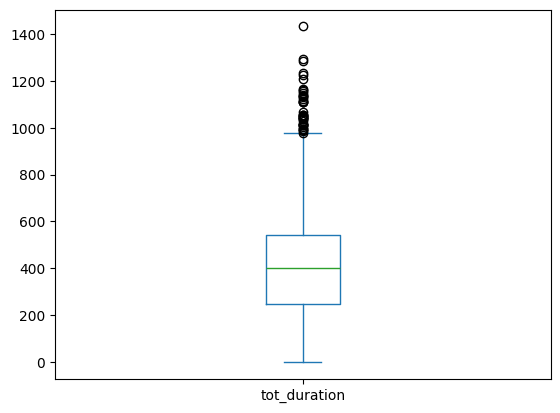

In [110]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

infor_tarif.plot(kind="box",x="plan",y="tot_duration" )


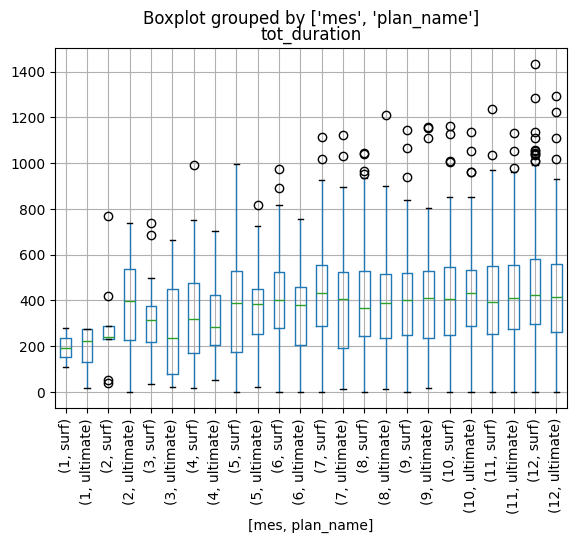

In [111]:
infor_tarif.boxplot(column="tot_duration",by=["mes","plan_name"])
plt.xticks(rotation=90)
plt.show()

Como podemos ver en nuestra grafica de caja el promedio es de 400 muy similar a lo que nos refleja en la tabla y en nuestra segunda grafica donde podemos ver el mes y nombre del plan y vemos que si varia el plan surf con el ultimate considerando que este ultimo es mas caro.

### Mensajes

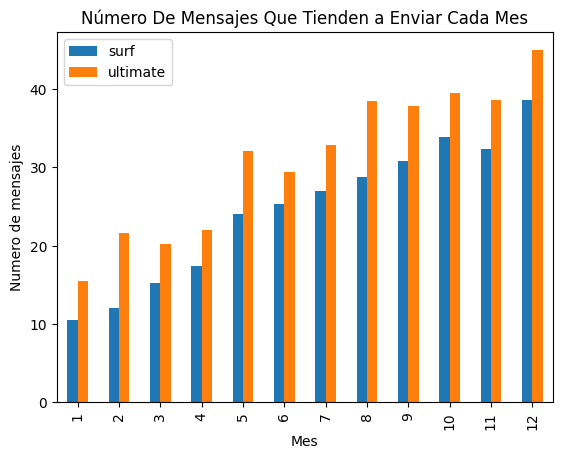

In [112]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
#paso 1 filtrar:
surf = infor_tarif[infor_tarif["plan_name"]=="surf"]
ultimate = infor_tarif[infor_tarif["plan_name"]=="ultimate"]

#paso 2 resumir por mes los minutos usados:
surf_min = surf.groupby("mes")["num_message"].mean()
ult_min = ultimate.groupby("mes")["num_message"].mean()

#paso 3 unir la información:
surf_ult = pd.concat([surf_min,ult_min],axis=1)

#paso 4 graficar:
surf_ult.plot(kind="bar",title="Número De Mensajes Que Tienden a Enviar Cada Mes",
              xlabel="Mes",
              ylabel="Numero de mensajes"
             )
plt.legend(["surf","ultimate"])
plt.show();

Aqui sacamos la duración promedio de mensajes por cada plan y cada mes, primero filtramos por cada plan, segundo resumimos por mes los minutos utilizando el método groupby(),la columna num_message y usando también el metodo mean(), unimos la informacion utilizando el método concat()y el parametro axis=1 y por último graficamos.

In [113]:
# Calcula la media y la varianza de la duración mensual de Mensajes.
surf_min_prom = surf.groupby("mes")["num_message"].mean()
surf_min_var = surf.groupby("mes")["num_message"].var()


ult_min_prom = ultimate.groupby("mes")["num_message"].mean()
ult_min_var = ultimate.groupby("mes")["num_message"].var()
print(f"el promedio de la duración mensual de mensajes para surf es:{surf_min_prom} ")
print(f"la varianza de la duración mensual de mensajes para surf es:{surf_min_var} ")
print(f"el promedio de la duración mensual de mensajes para ultimate es:{ult_min_prom} ")
print(f"la varianza de la duración mensual de mensajes para ultimate es:{ult_min_var} ")



el promedio de la duración mensual de mensajes para surf es:mes
1     10.500000
2     12.000000
3     15.260870
4     17.400000
5     24.012987
6     25.298969
7     27.033058
8     28.777778
9     30.762887
10    33.839662
11    32.385159
12    38.600629
Name: num_message, dtype: float64 
la varianza de la duración mensual de mensajes para surf es:mes
1      220.500000
2      386.000000
3      346.565217
4      501.591837
5      847.197198
6      914.920103
7      923.915565
8     1029.515528
9     1003.829496
10    1275.465708
11    1065.344034
12    1458.158612
Name: num_message, dtype: float64 
el promedio de la duración mensual de mensajes para ultimate es:mes
1     15.500000
2     21.571429
3     20.250000
4     22.047619
5     32.103448
6     29.340426
7     32.830508
8     38.478873
9     37.895349
10    39.443396
11    38.606299
12    45.006623
Name: num_message, dtype: float64 
la varianza de la duración mensual de mensajes para ultimate es:mes
1      313.666667
2      478.28

In [114]:
#media y varanza global por plan
infor_tarif.groupby("plan_name")["num_message"].describe()


,count,mean,std,min,25%,50%,75%,max
plan_name,,,,,,,,
surf,1573.0,31.159568,33.566717,0.0,3.0,24.0,47.0,266.0
ultimate,720.0,37.551389,34.767179,0.0,7.0,30.0,61.0,166.0


Aqui sacamos la media y varianza de la duración mensual y global de las mensajes donde podemos ver el conteo para surf 1573 clientes y ultimate 720, el  promedio de 31.15 en surf y 37.55 en ultimate y la desviación estandar 33.56 para surf y 34.76 para ultimate.

<Axes: >

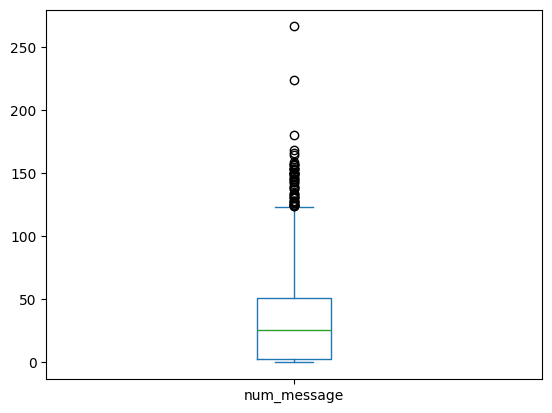

In [115]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de Mensajes

infor_tarif.plot(kind="box",x="plan",y="num_message" )


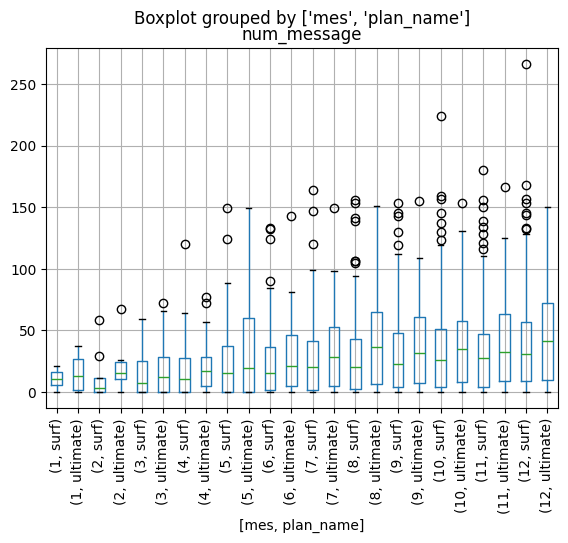

In [116]:
infor_tarif.boxplot(column="num_message",by=["mes","plan_name"])
plt.xticks(rotation=90)
plt.show()

Como podemos ver en nuestra grafica de caja el promedio entre 30 o 40 muy similar a lo que nos refleja en la tabla y en nuestra segunda grafica donde podemos ver que si varia el plan surf con el ultimate considerando que este ultimo es mas caro.

### Internet

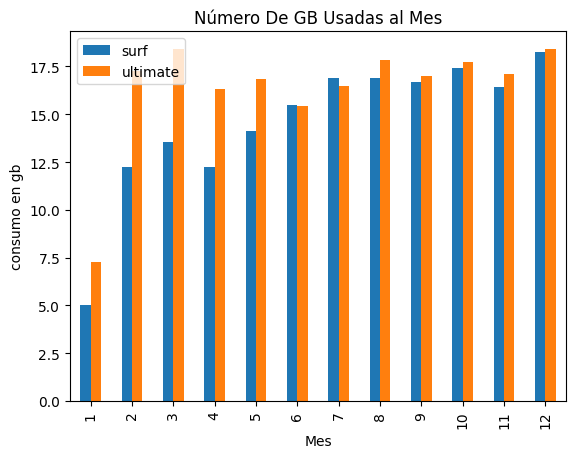

In [117]:
#filtrar por plan:
surf = infor_tarif[infor_tarif["plan_name"]=="surf"]
ultimate = infor_tarif[infor_tarif["plan_name"]=="ultimate"]

#resumir por mes los minutos:
surf_min = surf.groupby("mes")["gb_used"].mean()
ult_min = ultimate.groupby("mes")["gb_used"].mean()


#unir la información:
surf_ult = pd.concat([surf_min,ult_min],axis=1)


#graficar:
surf_ult.plot(kind="bar",title="Número De GB Usadas al Mes",
              xlabel="Mes",
              ylabel="consumo en gb"
             )
plt.legend(["surf","ultimate"])
plt.show();


Aqui sacamos la duración promedio de GB usadas por cada plan y cada mes, primero filtramos por cada plan, segundo resumimos por mes los minutos utilizando el método groupby(),la columna gb_used y usando también el metodo mean(), unimos la informacion utilizando el método concat()y el parametro axis=1 y por último graficamos.

In [118]:
# Calcula la media y la varianza de la duración mensual de gb utilizadas.
surf_min_prom = surf.groupby("mes")["gb_used"].mean()
surf_min_var = surf.groupby("mes")["gb_used"].var()


ult_min_prom = ultimate.groupby("mes")["gb_used"].mean()
ult_min_var = ultimate.groupby("mes")["gb_used"].var()
print(f"el promedio de la duración mensual de gigabytes para surf es:{surf_min_prom} ")
print(f"la varianza de la duración mensual de gigabytes para surf es:{surf_min_var} ")
print(f"el promedio de la duración mensual de gigabytes para ultimate es:{ult_min_prom} ")
print(f"la varianza de la duración mensual de gigabytes para ultimate es:{ult_min_var} ")


el promedio de la duración mensual de gigabytes para surf es:mes
1      5.000000
2     12.222222
3     13.565217
4     12.220000
5     14.116883
6     15.484536
7     16.876033
8     16.882716
9     16.690722
10    17.409283
11    16.431095
12    18.238994
Name: gb_used, dtype: float64 
la varianza de la duración mensual de gigabytes para surf es:mes
1     18.000000
2     41.444444
3     63.984190
4     56.215918
5     58.183527
6     47.752363
7     61.476171
8     71.420942
9     49.240639
10    60.725846
11    54.607824
12    69.210841
Name: gb_used, dtype: float64 
el promedio de la duración mensual de gigabytes para ultimate es:mes
1      7.250000
2     17.285714
3     18.416667
4     16.333333
5     16.862069
6     15.425532
7     16.491525
8     17.845070
9     17.011628
10    17.716981
11    17.118110
12    18.397351
Name: gb_used, dtype: float64 
la varianza de la duración mensual de gigabytes para ultimate es:mes
1      14.916667
2      37.904762
3     138.628788
4      85.83

In [119]:
#media y varanza global por plan
infor_tarif.groupby("plan_name")["gb_used"].describe()


,count,mean,std,min,25%,50%,75%,max
plan_name,,,,,,,,
surf,1573.0,16.670693,7.847522,0.0,12.0,17.0,21.0,70.0
ultimate,720.0,17.306944,7.670108,0.0,13.0,17.0,21.0,46.0


Aqui sacamos la media y varianza de la duración mensual y global de las GB usados donde podemos ver el conteo para surf 1573 clientes y ultimate 720, el  promedio de 16.67 en surf y 17.30 en ultimate y la desviación estandar 7.84 para surf y 7.67 para ultimate.

<Axes: >

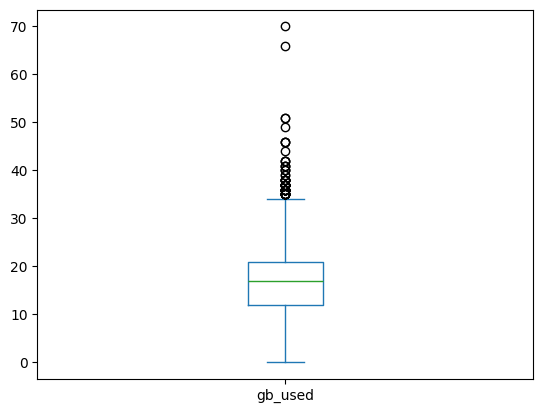

In [120]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de Gigabytes

infor_tarif.plot(kind="box",x="plan",y="gb_used" )



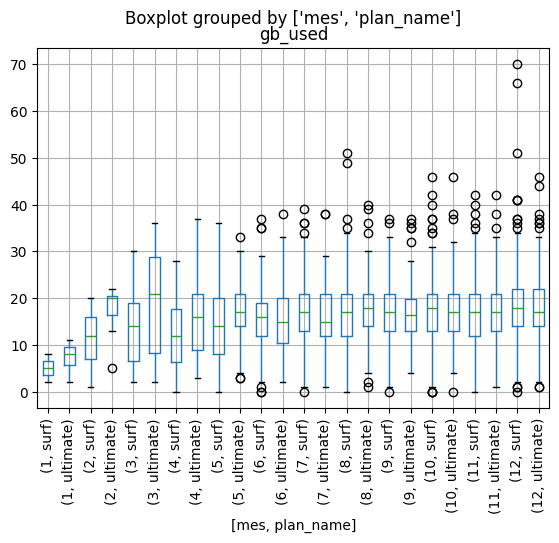

In [121]:
infor_tarif.boxplot(column="gb_used",by=["mes","plan_name"])
plt.xticks(rotation=90)
plt.show()

Como podemos ver en nuestra grafica de caja el promedio entre el 15 0 20 muy similar a lo que nos refleja en la tabla y en nuestra segunda grafica donde podemos ver que si varia el plan surf con el ultimate considerando que este ultimo es mas caro.

## Ingreso

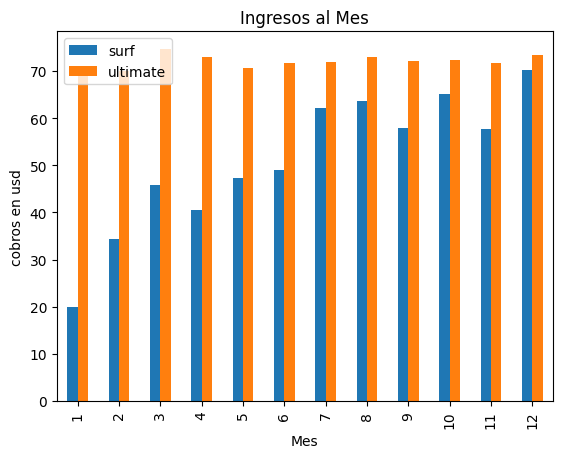

In [122]:
#filtrar por plan:
surf = infor_tarif[infor_tarif["plan_name"]=="surf"]
ultimate = infor_tarif[infor_tarif["plan_name"]=="ultimate"]

#resumir por mes los minutos:
surf_min = surf.groupby("mes")["ingresos"].mean()
ult_min = ultimate.groupby("mes")["ingresos"].mean()


#unir la información:
surf_ult = pd.concat([surf_min,ult_min],axis=1)


#graficar:
surf_ult.plot(kind="bar",title="Ingresos al Mes",
              xlabel="Mes",
              ylabel="cobros en usd"
             )
plt.legend(["surf","ultimate"])
plt.show();


Aqui sacamos el promedio de ingresos por cada plan y cada mes, primero filtramos por cada plan, segundo resumimos por mes los minutos utilizando el método groupby(),la columna ingresos y usando también el metodo mean(), unimos la informacion utilizando el método concat()y el parametro axis=1 y por último graficamos.

In [123]:
# Calcula la media y la varianza de los ingresos mensuales.
surf_min_prom = surf.groupby("mes")["ingresos"].mean()
surf_min_var = surf.groupby("mes")["ingresos"].var()


ult_min_prom = ultimate.groupby("mes")["ingresos"].mean()
ult_min_var = ultimate.groupby("mes")["ingresos"].var()
print(f"el promedio mensual de ingresos para surf es:{surf_min_prom} ")
print(f"la varianza mensual de ingresos para surf es:{surf_min_var} ")
print(f"el promedio mensual de ingresos para ultimate es:{ult_min_prom} ")
print(f"la varianza mensual de ingresos para ultimate es:{ult_min_var} ")


el promedio mensual de ingresos para surf es:mes
1     20.000000
2     34.256733
3     45.790261
4     40.454700
5     47.235155
6     48.930735
7     62.221942
8     63.572562
9     57.948540
10    65.046710
11    57.628813
12    70.102687
Name: ingresos, dtype: float64 
la varianza mensual de ingresos para surf es:mes
1        0.000000
2      429.972008
3     1507.606780
4     1196.879428
5     1949.819080
6     1977.719697
7     2921.294737
8     3572.648825
9     2252.218077
10    3179.188681
11    2485.276813
12    4590.574002
Name: ingresos, dtype: float64 
el promedio mensual de ingresos para ultimate es:mes
1     70.000000
2     70.000000
3     74.666667
4     73.000000
5     70.724138
6     71.638298
7     71.898305
8     72.859155
9     72.034884
10    72.311321
11    71.708661
12    73.291391
Name: ingresos, dtype: float64 
la varianza mensual de ingresos para ultimate es:mes
1       0.000000
2       0.000000
3     145.515152
4     120.400000
5      15.206897
6      75.01850

In [124]:
#media y varanza global por plan
infor_tarif.groupby("plan_name")["ingresos"].describe()

,count,mean,std,min,25%,50%,75%,max
plan_name,,,,,,,,
surf,1573.0,60.327346,55.262605,20.0,20.0,40.15,80.0,588.6372
ultimate,720.0,72.313889,11.395108,70.0,70.0,70.00,70.0,182.0000


Aqui sacamos la media y varianza  mensual y global de los ingresos donde podemos ver el conteo para surf 1573 clientes y ultimate 720, el  promedio de 60.32 en surf y 72.31 en ultimate y la desviación estandar 55.26 para surf y 11.39 para ultimate.

<Axes: >

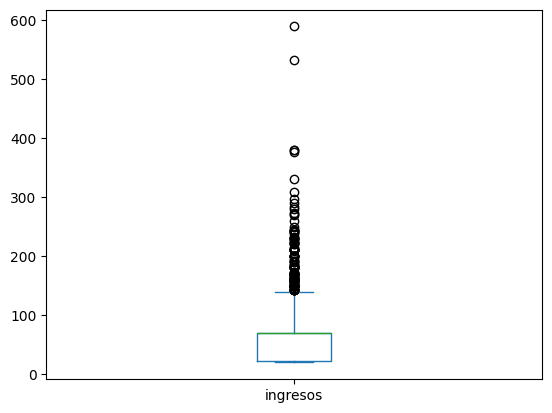

In [125]:
# Traza un diagrama de caja para visualizar la distribución de los ingresos mensuales

infor_tarif.plot(kind="box",x="plan",y="ingresos" )


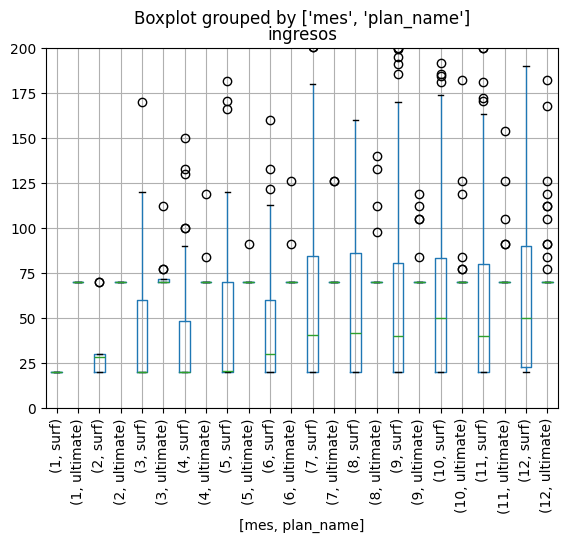

In [126]:
infor_tarif.boxplot(column="ingresos",by=["mes","plan_name"])
plt.xticks(rotation=90)
plt.ylim(0,200)
plt.show()

Como podemos ver en nuestra grafica de caja el promedio de 60 a 75 muy similar a lo que nos refleja en la tabla y en nuestra segunda grafica donde podemos ver que si varia el plan surf con el ultimate considerando que este ultimo es mas caro.

## Prueba las hipótesis estadísticas

In [127]:
# Prueba las hipótesis
# primer paso muestra de datos
surf = infor_tarif[infor_tarif["plan_name"]=="surf"]
surf = surf["ingresos"]

ultimate = infor_tarif[infor_tarif["plan_name"]=="ultimate"]
ultimate = ultimate["ingresos"]

In [128]:
#Imprimir variables
print(surf.var())
ultimate.var()

3053.9554654117874


np.float64(129.8484855509195)

In [129]:
#paso 3 pruebas de hipotesis
alpha=0.05
result = st.ttest_ind(surf,ultimate,equal_var=False)

print("p-value",result.pvalue)

if result.pvalue < alpha:
    print("Rechazamos la hipotesis nula")
else:
    print("No podemos rechazar la hipotesis nula")

p-value 3.5320199509520717e-16
Rechazamos la hipotesis nula


Aqui en la prueba de hipotesis como primer paso mostramos nuestros datos es decir fuimos a nuestra tabla donde tenemos la variable infor_tarif donde filtramos y extraimos la columna plan_name tanto para  surf como a ultimate, imprimimos las variables es decir sacamos las varianzas de ambas (aunque no lo piden) y por último las pruebas de hipotesis donde determine alpha=0.05 y el metodo ttest_ind() porque necesitamos comparar las medias de dos poblaciones estadisticamente diferentes,imprimimos y ponemos nuestro parametro (p-value,result.pvalue) y volvemos a imprimir con la frase rechazamos la hipotesis nula y otra donde no rechazamos la hipotesis nula, es asi como se hizo el planteamiento y nos dio el resultado que por cierto es muy elevado.

In [130]:
# Prueba las hipótesis
# primer paso muestra de datos
NY_NJ = infor_tarif[infor_tarif["city"].str.contains("NY-NJ")]
NY_NJ = NY_NJ["ingresos"]

San_Fra = infor_tarif[~infor_tarif["city"].str.contains("NY-NJ")]
San_Fra = San_Fra["ingresos"]


In [131]:
#Imprimir variables
print(NY_NJ.var())
San_Fra.var()

1890.2610271435337


np.float64(2216.886951570292)

In [132]:
#paso 3 pruebas de hipotesis
alpha=0.05
result = st.ttest_ind(NY_NJ,San_Fra,equal_var=False)

print("p-value",result.pvalue)

if result.pvalue < alpha:
    print("rechazamos la hipotesis nula")
else:
    print("No podemos rechazar la hipotesis nula")

p-value 0.031214139070912725
rechazamos la hipotesis nula


Aqui en la prueba de hipotesis como primer paso mostramos a los usuarios de los estados de NY-NJ es diferente a los usuarios de otras regiones, luego fuimos a nuestra tabla donde tenemos la variable infor_tarif donde filtramos y extraimos la columna city tanto para NY-NJ y San Francisco,utilizamos la herramienta de filtrado str.contains para NY-NJ y sacamos la columna ingresos, despúes con la variable San_Fra filtramos nuestra variable infor_tarif la columna city y NY_NJ y utilizamos la tilde(~) para demostrar o que es diferente a otros usuarios de otras regiones utilizamos la herramienta de filtrado y tambien extraemos la columna ingresos de nuestra variable San_Fra, imprimimos las variables es decir sacamos las varianzas de ambas (aunque no lo piden) y por último las pruebas de hipotesis donde determine alpha=0.05 y el metodo ttest_ind() porque necesitamos comparar las medias de dos poblaciones estadisticamente diferentes,imprimimos ponemos nuestro parametro (p-value,result.pvalue) y volvemos a imprimir con la frase rechazamos la hipotesis nula y otra donde no rechazamos la hipotesis nula es asi como se hizo el planteamiento y nos dio el resultado.

## Conclusión general
